# Machine Learning Model - Student Performance Prediction

## Objective
Build a regression model to predict **Exam Score** using given features.

## Dataset
Student Performance Factors Dataset

## Models Used
- Linear Regression
- Decision Tree
- Random Forest

## Evaluation Metrics
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")  
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Data Preprocessing
- Check missing values
- Handle categorical variables 
- Define features (X) and target (y)

In [4]:
# Check missing values
print(df.isnull().sum())

# If categorical columns exist → encode them
df = pd.get_dummies(df, drop_first=True)

# Define X and y
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [5]:
df.isnull().sum()

Hours_Studied                            0
Attendance                               0
Sleep_Hours                              0
Previous_Scores                          0
Tutoring_Sessions                        0
Physical_Activity                        0
Exam_Score                               0
Parental_Involvement_Low                 0
Parental_Involvement_Medium              0
Access_to_Resources_Low                  0
Access_to_Resources_Medium               0
Extracurricular_Activities_Yes           0
Motivation_Level_Low                     0
Motivation_Level_Medium                  0
Internet_Access_Yes                      0
Family_Income_Low                        0
Family_Income_Medium                     0
Teacher_Quality_Low                      0
Teacher_Quality_Medium                   0
School_Type_Public                       0
Peer_Influence_Neutral                   0
Peer_Influence_Positive                  0
Learning_Disabilities_Yes                0
Parental_Ed

## Train-Test Split
Split data into training and testing sets (80-20 split)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training
Train multiple regression models for comparison

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

## Model Evaluation Results
Compare models using RMSE, MAE, and R² Score

In [8]:
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
results_df.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
0,Linear Regression,1.804632,0.450285,0.769602
2,Random Forest,2.238094,1.181664,0.645629
1,Decision Tree,4.036520,1.959153,-0.152700


## Best Model Selection

The best model is selected based on:
- Lowest RMSE
- Highest R² Score

In [9]:
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Linear Regression


In [10]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

## Sample Predictions
Display predicted vs actual values

In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
0,65,64.541818
1,65,65.237684
2,71,71.536760
3,64,64.269738
4,66,66.526773


## Visualization: Actual vs Predicted

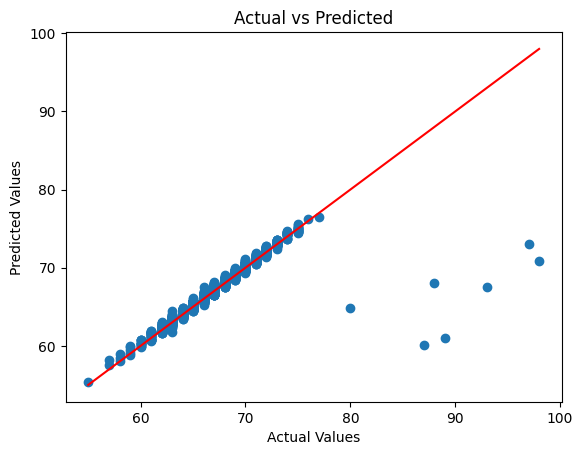

In [13]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)

# Ideal line (perfect prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()